# Comparação de modelos — Breast Cancer Survival Prediction

Este notebook consolida e compara os quatro modelos treinados no projeto Marchine Breast Cancer:

**Contexto do problema:**  
Classificação binária: prever se uma paciente está **Alive (0)** ou **Dead (1)** após tratamento de câncer de mama.  
O dataset apresenta **desbalanceamento natural** — 682 Alive vs 123 Dead no conjunto de teste (85% / 15%).

## Carregamento das métricas

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.size'] = 11
sns.set_palette('Set2')

In [3]:
metrics = {
    'Modelo': ['Dummy Classifier', 'Naive Bayes', 'Random Forest', 'XGBoost (tuned)'],
    'Acurácia':  [0.8472, 0.7627, 0.7938, 0.8224],
    'Precisão':  [0.0000, 0.3046, 0.3252, 0.3864],
    'Recall':    [0.0000, 0.4309, 0.3252, 0.2764],
    'F1-score':  [0.0000, 0.3569, 0.3252, 0.3223],
    'AUC-ROC':   [0.5000, 0.6267, 0.6018, 0.5986],

    'VP (Dead)': [0,    53,  40,  29],
    'FP':        [0,   121,  83,  49],
    'FN':        [123,  70,  83,  94],
    'VN (Alive)':[682, 561, 599, 633],
}

df = pd.DataFrame(metrics).set_index('Modelo')

display(df[['Acurácia', 'Precisão', 'Recall', 'F1-score', 'AUC-ROC']].style
    .format('{:.4f}')
    .background_gradient(cmap='RdYlGn', axis=0)
    .set_caption('Métricas comparativas — conjunto de teste (n=805)')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

,Acurácia,Precisão,Recall,F1-score,AUC-ROC
Modelo,,,,,
Dummy Classifier,0.8472,0.0000,0.0000,0.0000,0.5000
Naive Bayes,0.7627,0.3046,0.4309,0.3569,0.6267
Random Forest,0.7938,0.3252,0.3252,0.3252,0.6018
XGBoost (tuned),0.8224,0.3864,0.2764,0.3223,0.5986


### Análise individual por modelo

### Dummy Classifier — Linha de Base

O Dummy Classifier é o ponto de referência zero do projeto. Ele ignora completamente os dados de entrada e sempre prediz a classe majoritária (Alive = 0), estratégia chamada de most frequent.

Mas tipo, por que 84,7% de acurácia sem aprender nada?
Porque o dataset é desbalanceado, 84,7% das pacientes são Alive no teste. Isso revela uma armadilha da acurácia: um modelo que nunca acerta um único caso de morte parece ter bom desempenho quando olhamos só para essa métrica.

Pontos-chave:
- Precisão/Recall/F1 para a classe Dead = 0.000 (literalmente inútil para o objetivo clínico)
- AUC-ROC = 0.500 (equivalente a jogar uma moeda)
- VP (Verdadeiros Positivos para Dead) = 0 — nenhum caso de morte identificado

> Qualquer modelo real precisa superar esses números para justificar seu uso.

### Naive Bayes — Primeiro modelo real

O GaussianNB assume independência condicional entre as features dado o rótulo, e modela cada feature como uma distribuição gaussiana. É simples, rápido e surpreendentemente competitivo em dados médicos.

O que funcionou:
O treinamento usou **SMOTE** para balancear as classes (2.725 amostras de cada), o que ajudou o modelo a "enxergar" a classe Dead. Resultado: **Recall de 43%** — o melhor dentre todos os modelos para identificar mortes.

**Limitação central:**  
A independência entre features raramente se sustenta em dados clínicos. Features como `Reginol_Node_Positive`, `Tumor_Size` e `N_Stage` são altamente correlacionadas, e o Naive Bayes não captura essas relações. Isso limita a precisão a apenas 30,5%.

**Pontos-chave:**
- Melhor **Recall** (43,1%) — identifica mais casos de morte que qualquer outro modelo
- Pior **Acurácia** (76,3%) — gera mais falsos alarmes (FP = 121)
- AUC-ROC = 0.627 — melhor discriminação geral entre os 4 modelos
- Tuning (GridSearchCV sobre `var_smoothing`) confirmou os mesmos parâmetros padrão

### Random Forest — Ensemble robusto

O Random Forest constrói 100 árvores de decisão com subsets aleatórios de dados e features, reduzindo variância por *bagging*. É naturalmente resistente a overfitting e captura relações não-lineares.

**Comportamento curioso — Recall = Precisão = F1 = 0.325:**  
Esse empate acontece quando o modelo gera exatamente o mesmo número de FP e FN (83 = 83). É uma coincidência estatística dos dados, não uma propriedade do algoritmo.

**Features mais importantes (por impurity gain):**
1. `Reginol_Node_Positive` (21.3%) — principal preditor clínico
2. `Tumor_Size` (16.1%) e `Age` (15.9%) — muito próximos, ambos relevantes
3. `Regional_Node_Examined` (15.9%)

> O modelo equilibra bem Alive e Dead (40 VP, 83 FP, 83 FN), mas o tuning com GridSearch não melhorou os parâmetros (melhores = padrão), sugerindo que o gargalo é o desbalanceamento residual no conjunto de teste, não a capacidade do modelo.

**Pontos-chave:**
- Acurácia intermediária (79,4%)
- AUC-ROC = 0.602 — ligeiramente abaixo do Naive Bayes
- Melhor recall no CV (89,9%) — forte generalização com SMOTE no treino

### XGBoost — Gradient Boosting otimizado

O XGBoost constrói árvores **sequencialmente**, onde cada nova árvore corrige os erros da anterior usando gradiente descendente na função de perda. É o estado-da-arte para dados tabulares estruturados.

**Por que a acurácia mais alta (82,2%)?**  
O boosting sequencial concentra esforço nos exemplos difíceis, ajustando pesos. Com `max_depth=7` e `learning_rate=0.1`, o modelo aprendeu fronteiras de decisão mais precisas para a classe majoritária (Alive), resultando em 633 VN vs 682 possíveis.

**O trade-off de precisão vs recall:**  
O XGBoost tem a **maior precisão** (38,6%) mas o **pior recall** (27,6%) entre os modelos reais. Isso significa que quando ele prevê uma morte, está mais frequentemente certo — mas deixa passar mais casos reais de morte (94 FN).

**Features mais importantes (XGBoost gain):**
1. `Reginol_Node_Positive` (19.9%) — consistente com Random Forest
2. `Estrogen_Status` (17.2%) — **muito mais relevante que no RF** (2.4% no RF!)
3. `Progesterone_Status` (14.6%) — também subestimado pelo RF

> O XGBoost "descobriu" que o status hormonal (estrógeno/progesterona) tem muito mais poder preditivo do que o Random Forest estimou. Isso faz sentido clinicamente: tumores HR+ têm melhor prognóstico.

**Parâmetros otimizados:** `colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=100, subsample=0.8`

### Visualizações comparativas

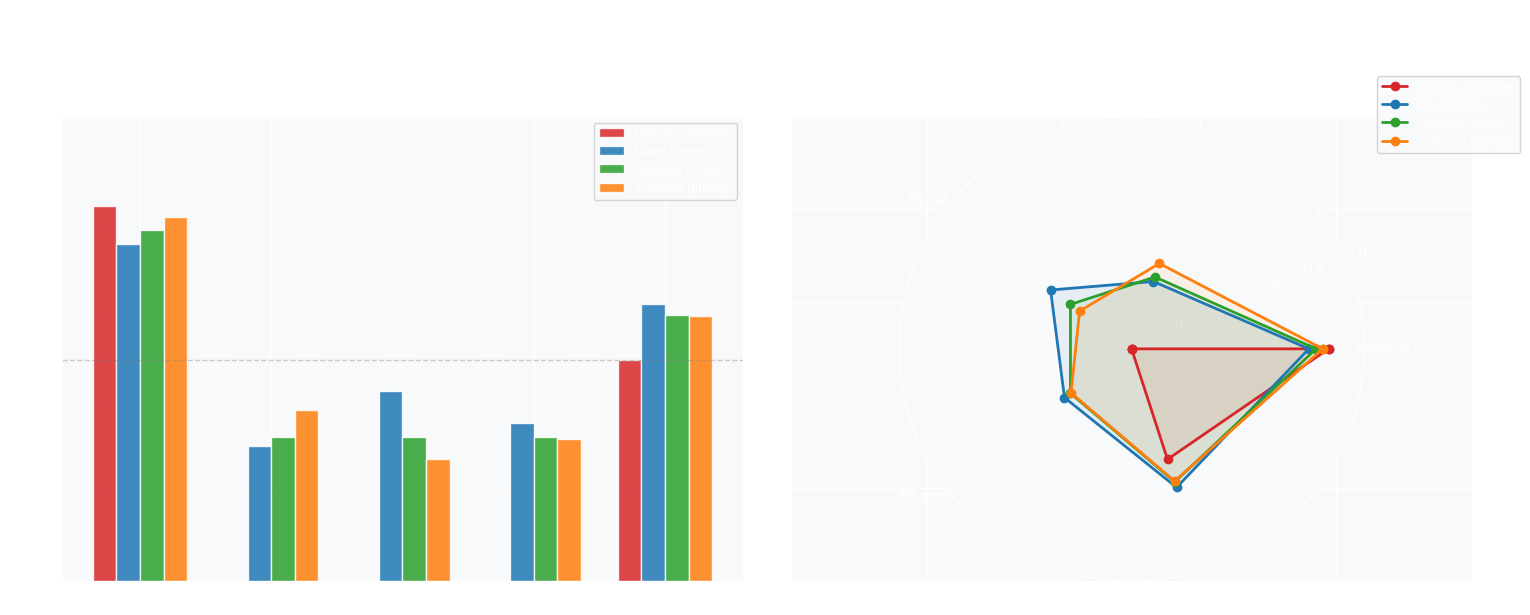

Figura salva: comparison_metrics.png


In [4]:
modelos = ['Dummy\nClassifier', 'Naive\nBayes', 'Random\nForest', 'XGBoost\n(tuned)']
cores   = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']

metricas_plot = {
    'Acurácia':  [0.8472, 0.7627, 0.7938, 0.8224],
    'Precisão':  [0.0000, 0.3046, 0.3252, 0.3864],
    'Recall':    [0.0000, 0.4309, 0.3252, 0.2764],
    'F1-score':  [0.0000, 0.3569, 0.3252, 0.3223],
    'AUC-ROC':   [0.5000, 0.6267, 0.6018, 0.5986],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparação de Métricas entre Modelos', fontsize=16, fontweight='bold', y=1.02)

ax = axes[0]
x = np.arange(len(metricas_plot))
width = 0.18
for i, (modelo, cor) in enumerate(zip(modelos, cores)):
    valores = [metricas_plot[m][i] for m in metricas_plot]
    bars = ax.bar(x + i*width, valores, width, label=modelo.replace('\n', ' '), color=cor, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(list(metricas_plot.keys()), fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Todas as métricas por modelo', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(axis='y', alpha=0.3)

ax2 = fig.add_subplot(122, projection='polar')
categorias = list(metricas_plot.keys())
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

ax2.set_facecolor('#f8f9fa')
for i, (modelo, cor) in enumerate(zip(modelos, cores)):
    valores_radar = [metricas_plot[m][i] for m in categorias]
    valores_radar += valores_radar[:1]
    ax2.plot(angulos, valores_radar, 'o-', linewidth=2, color=cor, label=modelo.replace('\n', ' '))
    ax2.fill(angulos, valores_radar, alpha=0.08, color=cor)

ax2.set_xticks(angulos[:-1])
ax2.set_xticklabels(categorias, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title('Perfil de cada modelo', fontsize=13, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: comparison_metrics.png')

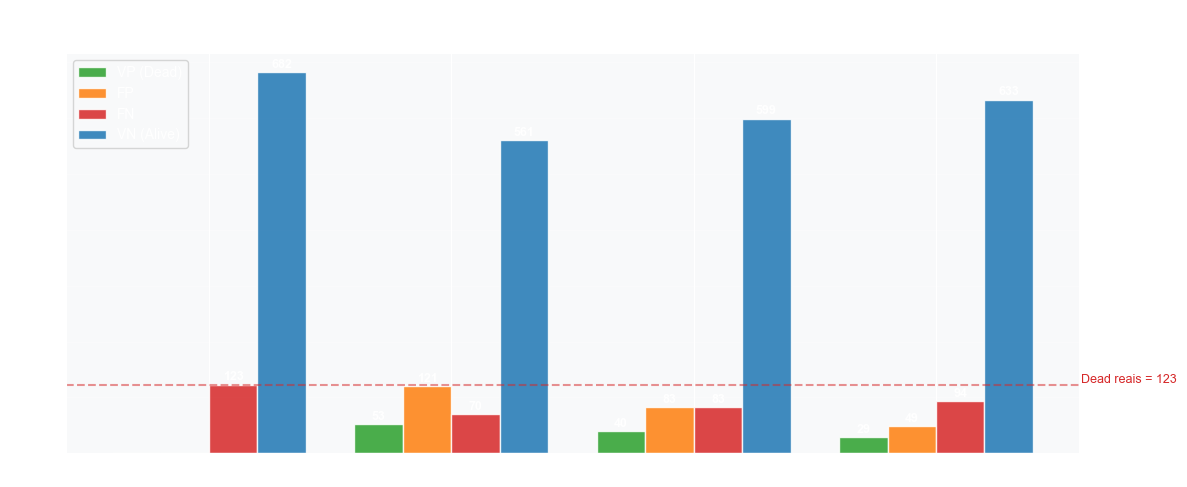

In [6]:
cm_data = {
    'Modelo':       ['Dummy', 'Naive Bayes', 'Random Forest', 'XGBoost'],
    'VP (Dead)':    [0,   53, 40, 29],
    'FP':           [0,  121, 83, 49],
    'FN':           [123, 70, 83, 94],
    'VN (Alive)':   [682,561,599,633],
}
df_cm = pd.DataFrame(cm_data).set_index('Modelo')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_cm))
w = 0.2
cores_cm = {'VP (Dead)': '#2ca02c', 'FP': '#ff7f0e', 'FN': '#d62728', 'VN (Alive)': '#1f77b4'}

for i, (col, cor) in enumerate(cores_cm.items()):
    bars = ax.bar(x + i*w, df_cm[col], w, label=col, color=cor, alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2., h + 2, str(int(h)),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(df_cm.index, fontsize=11)
ax.set_ylabel('Número de amostras', fontsize=12)
ax.set_title('Distribuição dos resultados da matriz de confusão por modelo\n(n=805 | Alive=682 | Dead=123)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

ax.axhline(123, color='#d62728', linestyle='--', alpha=0.5, linewidth=1.5, label='Total real Dead=123')
ax.text(3.9, 126, 'Dead reais = 123', color='#d62728', fontsize=9)

plt.tight_layout()
plt.savefig('confusion_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

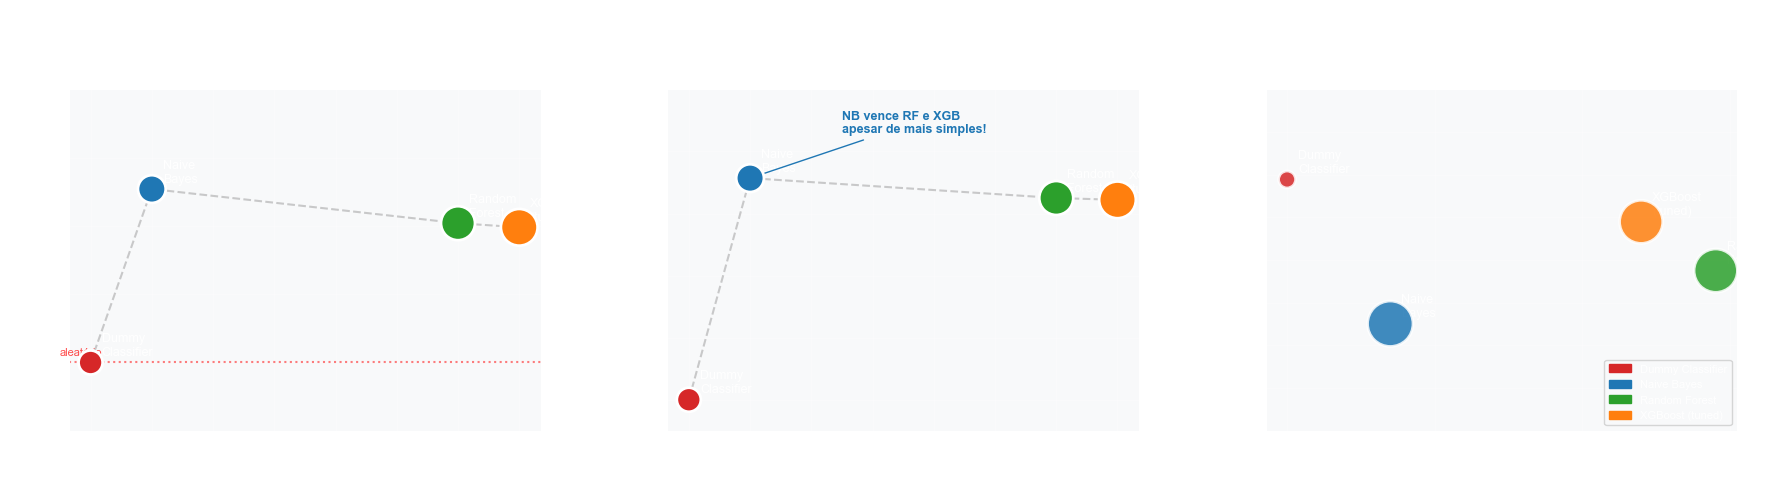

In [7]:
complexidade     = [1, 2, 7, 8]
interpretab      = [10, 7, 4, 3]
tempo_treino_rel = [0.01, 0.05, 8.0, 2.5]
f1_dead          = [0.000, 0.357, 0.325, 0.322]
auc              = [0.500, 0.627, 0.602, 0.599]
nomes = ['Dummy\nClassifier', 'Naive\nBayes', 'Random\nForest', 'XGBoost\n(tuned)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Como os modelos escalam — Complexidade × Resultado', fontsize=15, fontweight='bold')

ax = axes[0]
scatter = ax.scatter(complexidade, auc, s=[300, 400, 600, 700], c=cores, zorder=5, edgecolors='white', linewidth=2)
for i, nome in enumerate(nomes):
    ax.annotate(nome, (complexidade[i], auc[i]), 
                textcoords='offset points', xytext=(8, 5), fontsize=9)
ax.plot(complexidade, auc, '--', color='gray', alpha=0.4, zorder=1)
ax.set_xlabel('Complexidade do modelo (1=simples, 10=complexo)', fontsize=10)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('Complexidade vs Discriminação (AUC)', fontsize=12, fontweight='bold')
ax.set_ylim(0.45, 0.7)
ax.axhline(0.5, color='red', linestyle=':', alpha=0.5)
ax.text(0.5, 0.505, 'aleatório', color='red', fontsize=8, alpha=0.7)
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(complexidade, f1_dead, s=[300, 400, 600, 700], c=cores, zorder=5, edgecolors='white', linewidth=2)
for i, nome in enumerate(nomes):
    ax.annotate(nome, (complexidade[i], f1_dead[i]),
                textcoords='offset points', xytext=(8, 5), fontsize=9)
ax.plot(complexidade, f1_dead, '--', color='gray', alpha=0.4, zorder=1)
ax.set_xlabel('Complexidade do modelo', fontsize=10)
ax.set_ylabel('F1-score (classe Dead)', fontsize=11)
ax.set_title('Complexidade vs F1 (Dead)', fontsize=12, fontweight='bold')
ax.set_ylim(-0.05, 0.5)
ax.grid(alpha=0.3)

ax.annotate('NB vence RF e XGB\napesar de mais simples!',
            xy=(2, 0.357), xytext=(3.5, 0.43),
            arrowprops=dict(arrowstyle='->', color='#1f77b4'),
            color='#1f77b4', fontsize=9, fontweight='bold')

ax = axes[2]
acuracia = [0.8472, 0.7627, 0.7938, 0.8224]
bubble_sizes = [max(f*3000, 100) for f in f1_dead]
bubble_sizes[0] = 150
sc = ax.scatter(tempo_treino_rel, acuracia, s=bubble_sizes, c=cores, zorder=5, 
                edgecolors='white', linewidth=2, alpha=0.85)
for i, nome in enumerate(nomes):
    ax.annotate(nome, (tempo_treino_rel[i], acuracia[i]),
                textcoords='offset points', xytext=(8, 5), fontsize=9)
ax.set_xlabel('Tempo relativo de treino (log scale)', fontsize=10)
ax.set_ylabel('Acurácia geral', fontsize=11)
ax.set_xscale('log')
ax.set_title('Custo × Acurácia\n(tamanho = F1 Dead)', fontsize=12, fontweight='bold')
ax.set_ylim(0.70, 0.90)
ax.grid(alpha=0.3)

legend_sizes = [mpatches.Patch(color=c, label=n.replace('\n', ' ')) 
                for c, n in zip(cores, nomes)]
ax.legend(handles=legend_sizes, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

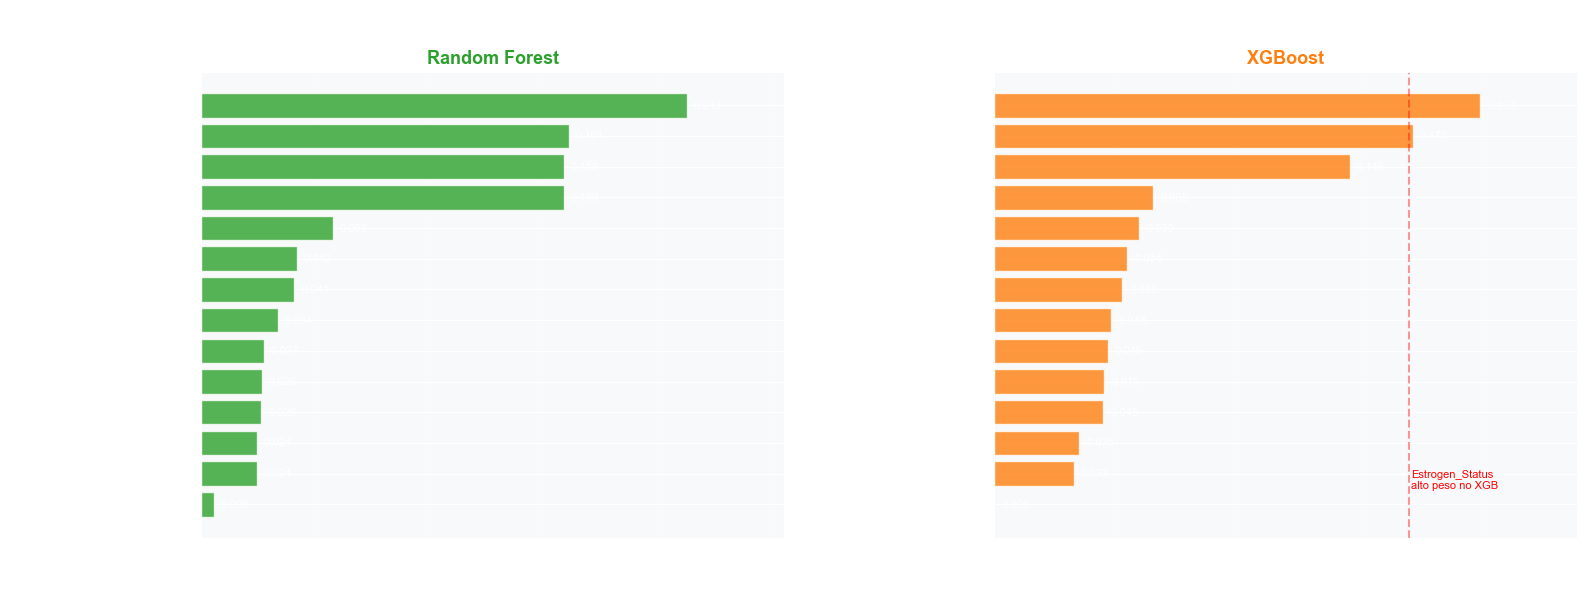

In [8]:
features = ['Reginol_Node_Positive', 'Tumor_Size', 'Age', 'Regional_Node_Examined',
            'Marital_Status', '6th_Stage', 'Progesterone_Status', 'Race',
            'N_Stage', 'T_Stage', 'differentiate', 'Grade', 'Estrogen_Status', 'A_Stage']

rf_importance  = [0.2131, 0.1613, 0.1590, 0.1589, 0.0577, 0.0418, 0.0408, 0.0335,
                  0.0273, 0.0264, 0.0262, 0.0243, 0.0242, 0.0055]
xgb_importance = [0.1993, 0.0545, 0.0480, 0.0526, 0.0465, 0.0447, 0.1458, 0.0651,
                  0.0348, 0.0450, 0.0595, 0.0000, 0.1717, 0.0325]

df_imp = pd.DataFrame({
    'Feature': features,
    'Random Forest': rf_importance,
    'XGBoost': xgb_importance
}).sort_values('Random Forest', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance: Random Forest vs XGBoost', fontsize=15, fontweight='bold')

for ax, modelo, cor in zip(axes, ['Random Forest', 'XGBoost'], ['#2ca02c', '#ff7f0e']):
    df_sorted = df_imp.sort_values(modelo, ascending=True)
    bars = ax.barh(df_sorted['Feature'], df_sorted[modelo], color=cor, alpha=0.8, edgecolor='white')
    ax.set_xlabel('Importância relativa', fontsize=11)
    ax.set_title(modelo, fontsize=13, fontweight='bold', color=cor)
    ax.grid(axis='x', alpha=0.3)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.003, bar.get_y() + bar.get_height()/2., f'{w:.3f}',
                va='center', fontsize=8)
    ax.set_xlim(0, max(df_imp[modelo]) * 1.2)

axes[1].axvline(0.17, color='red', linestyle='--', alpha=0.4)
axes[1].text(0.171, 0.5, 'Estrogen_Status\nalto peso no XGB', color='red', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Tabela consolidada de comparação

In [9]:
df_full = pd.DataFrame({
    'Modelo':           ['Dummy', 'Naive Bayes', 'Random Forest', 'XGBoost (tuned)'],
    'Acurácia':         [0.8472, 0.7627, 0.7938, 0.8224],
    'Precisão (Dead)':  [0.0000, 0.3046, 0.3252, 0.3864],
    'Recall (Dead)':    [0.0000, 0.4309, 0.3252, 0.2764],
    'F1 (Dead)':        [0.0000, 0.3569, 0.3252, 0.3223],
    'AUC-ROC':          [0.5000, 0.6267, 0.6018, 0.5986],
    'VP (Dead)':        [0, 53, 40, 29],
    'FP':               [0, 121, 83, 49],
    'FN':               [123, 70, 83, 94],
    'Complexidade':     ['Mínima', 'Baixa', 'Alta', 'Alta'],
    'Tuning aplicado':  ['Não', 'Sim (var_smoothing)', 'Sim (n_est, depth)', 'Sim (5 parâmetros)'],
    '🏆 Melhor em':     [
        'Nada (baseline)',
        'Recall, AUC-ROC',
        'Equilíbrio FP/FN',
        'Acurácia, Precisão'
    ]
}).set_index('Modelo')

display(df_full.style
    .format({'Acurácia': '{:.4f}', 'Precisão (Dead)': '{:.4f}', 'Recall (Dead)': '{:.4f}',
             'F1 (Dead)': '{:.4f}', 'AUC-ROC': '{:.4f}'})
    .background_gradient(subset=['Acurácia', 'Precisão (Dead)', 'Recall (Dead)', 'F1 (Dead)', 'AUC-ROC'], cmap='YlGn')
    .set_caption('📋 Tabela consolidada — todos os modelos e todas as métricas')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

,Acurácia,Precisão (Dead),Recall (Dead),F1 (Dead),AUC-ROC,VP (Dead),FP,FN,Complexidade,Tuning aplicado,🏆 Melhor em
Modelo,,,,,,,,,,,
Dummy,0.8472,0.0000,0.0000,0.0000,0.5000,0,0,123,Mínima,Não,Nada (baseline)
Naive Bayes,0.7627,0.3046,0.4309,0.3569,0.6267,53,121,70,Baixa,Sim (var_smoothing),"Recall, AUC-ROC"
Random Forest,0.7938,0.3252,0.3252,0.3252,0.6018,40,83,83,Alta,"Sim (n_est, depth)",Equilíbrio FP/FN
XGBoost (tuned),0.8224,0.3864,0.2764,0.3223,0.5986,29,49,94,Alta,Sim (5 parâmetros),"Acurácia, Precisão"



## Como cada modelo escalou

### Da baseline ao estado-da-arte

```
Dummy ──► Naive Bayes ──► Random Forest ──► XGBoost
  │              │               │               │
  │         +AUC 0.13       +Acurácia 0.03   +Precisão 0.06
  │         +Recall 0.43    ~Recall (=NB)    -Recall 0.15
  │         Custo: mínimo   Custo: alto      Custo: médio
```

**O salto mais valioso:** De Dummy → Naive Bayes. Com mínima complexidade adicional e custo de treino irrisório, o Naive Bayes ganhou +12,7 pontos de AUC-ROC e passou de 0 para 53 casos de morte identificados.

**O trade-off mais evidente:** Random Forest → XGBoost. Apesar do XGBoost ser mais sofisticado e ter mais parâmetros tunados, a melhoria em acurácia (+2,9 pp) veio à custa de perder 11 verdadeiros positivos (40 VP → 29 VP) e reduzir o Recall em 4,9 pp.

**Por que o XGBoost tem a maior acurácia mas não o melhor F1?**  
O boosting priorizou minimizar o erro geral, que é dominado pela classe Alive (85% dos dados). Com `max_depth=7`, o modelo aprendeu fronteiras muito específicas para casos de Alive, aumentando os VN (633 vs 599 do RF) mas deixando passar mais mortes (FN=94 vs 83 do RF).

**Insight de escala:**  
Para esse problema clínico específico, adicionar complexidade (RF e XGB) **não melhorou** o que realmente importa — detectar mortes. O Naive Bayes, apesar de ser o mais antigo e simples dos três modelos reais, mantém a liderança em F1 (Dead) = 0.357 e AUC-ROC = 0.627.

Isso sugere que os ganhos futuros virão não de algoritmos mais complexos, mas de:
1. **Mais dados** ou melhor técnica de balanceamento (além do SMOTE)
2. **Feature engineering** — criação de variáveis compostas (ex: razão linfonodos positivos/examinados)
3. **Threshold tuning** — ajustar o limiar de decisão para priorizar Recall no contexto clínico